# **Disaster Tweet NLP Dataset**


Twitter has become a critical communication channel during emergencies. Due to the widespread use of smartphones and internet connectivity, people can report events in real time from almost anywhere in the world. This immediacy makes social media platforms—especially Twitter—valuable sources of information for organizations involved in disaster response and monitoring.

Government agencies, disaster relief organizations, and news outlets increasingly rely on automated systems to monitor Twitter streams in order to detect potential disasters quickly. By analyzing tweets, these organizations can identify emerging situations such as earthquakes, floods, fires, or other emergencies and respond more efficiently.

However, a major challenge is distinguishing between tweets that actually report a real disaster and tweets that use similar words in a figurative or unrelated context.

The main goal is to train machine learning or deep learning models to classify tweets into two categories:

- **Disaster-related tweets (1)** — tweets that refer to a real emergency or disaster event.
- **Non-disaster tweets (0)** — tweets that use disaster-related words metaphorically or in unrelated contexts.



# **1) Exploratory Data Analysis (EDA)** 


### Libraries

In [162]:
import sys
!{sys.executable} -m pip install langdetect

     ---------------------------------------- 0.0/981.5 kB ? eta -:--:--
     ------------------------------------- 981.5/981.5 kB 11.9 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993364 sha256=603580aceff066a9a670fc7bddc9f22f615da5b39d07b3ecebfeec650f607aa4
  Stored in directory: c:\users\ale\appdata\local\pip\cache\wheels\eb\87\25\2dddf1c94e1786054e25022ec5530bfed52bad86d882999c48
Successfully built langdetect



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [163]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
from sklearn.feature_extraction.text import CountVectorizer
from itertools import combinations
from collections import Counter
import nltk
from nltk.corpus import stopwords
from langdetect import detect

### Load dataset

In [2]:
df = pd.read_csv("train.csv")

## **1. Dataset Overview**

### **1. Columns**
Using the methods `.head()`, `.shape`, and `.info()`, we can inspect the structure and basic properties of the dataset. These functions allow us to view sample rows, determine the dataset dimensions, and examine the data types and presence of missing values.



In [3]:
df.head()

,id,keyword,location,text,target
0,1,NaN,NaN,Our Deeds are the Reason of this #earthquake M...,1
1,4,NaN,NaN,Forest fire near La Ronge Sask. Canada,1
2,5,NaN,NaN,All residents asked to 'shelter in place' are ...,1
3,6,NaN,NaN,"13,000 people receive #wildfires evacuation or...",1
4,7,NaN,NaN,Just got sent this photo from Ruby #Alaska as ...,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7613 entries, 0 to 7612
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        7613 non-null   int64
 1   keyword   7552 non-null   str  
 2   location  5080 non-null   str  
 3   text      7613 non-null   str  
 4   target    7613 non-null   int64
dtypes: int64(2), str(3)
memory usage: 1.2 MB


In [5]:
df.shape

(7613, 5)

From this inspection, we identify the following columns in the dataset.

| Feature | Description |
|-------|-------------|
| `id` | Unique identifier for each tweet |
| `text` | The actual content of the tweet |
| `keyword` | A disaster-related keyword associated with the tweet (optional) |
| `location` | The location mentioned in the tweet, if provided |
| `target` | Label indicating whether the tweet refers to a real disaster (1) or not (0) |



### **1.2 Data Types and Missing Values Analysis**

Using the methods `.dtypes` and `.isnull().sum()`, we can further inspect the dataset to understand the **data types of each column** and the **presence of missing values**.

In [6]:
df.dtypes

id          int64
keyword       str
location      str
text          str
target      int64
dtype: object

In [7]:
df.isnull().sum()

id             0
keyword       61
location    2533
text           0
target         0
dtype: int64

From this analysis, we observe that:

- The `keyword` column contains **61 missing values**.
- The `location` column contains **2533 missing values**, representing a significant portion of the dataset.
- The columns `id`, `text`, and `target` contain **no missing values**.

### **1.3 Cardinality and Unique Values**

We will find the number of unique users locations, hastags and labels

In [18]:
def unique_users(df):
    unique_users = df['id'].nunique()
    total_users = df['id'].count()
    if total_users == 0:
        return "No users found."
    else:
        if unique_users == total_users:
            return "All users are unique: " + str(unique_users)
        else:
            repetitions = total_users - unique_users
            return "Unique users: " + str(unique_users) + ", Total users: " + str(total_users) + ", Repetitions: " + str(repetitions)

def unique_locations(df):
    unique_locations = df['location'].nunique()
    total_locations = df['location'].count()
    if total_locations == 0:
        return "No locations found."
    else:
        if unique_locations == total_locations:
            return "All locations are unique: " + str(unique_locations)
        else:
            repetitions = total_locations - unique_locations
            return "Unique locations: " + str(unique_locations) + ", Total locations: " + str(total_locations) + ", Repetitions: " + str(repetitions)
    return df['location'].nunique()


def unique_keywords(df):
    unique_keywords = df['keyword'].nunique()
    total_keywords = df['keyword'].count()
    if total_keywords == 0:
        return "No keywords found."
    else:
        if unique_keywords == total_keywords:
            return "All keywords are unique: " + str(unique_keywords)
        else:
            repetitions = total_keywords - unique_keywords
            return "Unique keywords: " + str(unique_keywords) + ", Total keywords: " + str(total_keywords) + ", Repetitions: " + str(repetitions)
    return df['keyword'].nunique()


def unique_hashtags(df):
    hashtags = set()
    total_hashtags = 0
    
    for tweet in df['text']:
        words = tweet.split()
        for word in words:
            if word.startswith('#'):
                hashtags.add(word.lower())
                total_hashtags += 1

    unique_hashtags_list = list(hashtags)
    unique_hashtags_count = len(hashtags)

    if unique_hashtags_count == 0:
        return "No hashtags found."
    
    if unique_hashtags_count == total_hashtags:
        return f"All hashtags are unique: {unique_hashtags_count}"
    
    repetitions = total_hashtags - unique_hashtags_count
    
    return (
        f"Unique hashtags: {unique_hashtags_count}, "
        f"Total hashtags: {total_hashtags}, "
        f"Repetitions: {repetitions} "
    )

def unique_target(df): 
    unique_targets = df['target'].nunique()
    if df['target'].nunique() == 0:
        return "No target values found."
    else:
        if unique_targets != 2:
            return "Unexpected number of unique target values: " + str(unique_targets)
        else:
            return "Unique target values: " + str(unique_targets)


In [9]:
unique_users(df)

'All users are unique: 7613'

The dataset contains **7613 unique users**, which matches the total number of tweets. This indicates that each tweet is associated with a unique identifier in the dataset.

In [10]:
unique_locations(df)

'Unique locations: 3341, Total locations: 5080, Repetitions: 1739'

This suggests that many locations appear multiple times, likely corresponding to commonly referenced places.

In [11]:
unique_keywords(df)

'Unique keywords: 221, Total keywords: 7552, Repetitions: 7331'

This indicates that while there are many different keywords, most tweets reuse a relatively small subset of them.

In [20]:
unique_hashtags(df)


'Unique hashtags: 1965, Total hashtags: 3340, Repetitions: 1375 '

This suggests that hashtags are frequently used but many appear only a few times, reflecting the informal and user-generated nature of Twitter content.

In [21]:
unique_target(df)

'Unique target values: 2'

This confirms that the problem is a **binary classification task**.

## **2. Text Quality and Cleaning**

### **2.1 Duplicate tweets and retweets**

To reduce bias in the dataset, duplicate tweets and retweets were identified and removed. Duplicate tweets were detected by checking repeated values in the `text` column, ensuring that identical tweet content does not appear multiple times in the dataset.

Additionally, retweets were identified by detecting tweets that start with the prefix `RT`, which typically indicates that the message is a repost of another user's tweet. Retweets often replicate the same information and may introduce redundancy in the dataset.

In [23]:
def delete_duplicates(df):

    duplicates = df.duplicated(subset='text').sum()
    retweets = df['text'].str.startswith('RT')
    retweets_count = retweets.sum()

    if duplicates != 0 or retweets_count != 0:
        print(f"There are {duplicates} duplicate tweets")
        print(f"There are {retweets_count} retweets")
    else:
        print("The dataset does not have duplicate tweets or retweets")

    # Remove duplicates
    df = df.drop_duplicates(subset='text')

    # Remove retweets
    df = df[~df['text'].str.startswith('RT')]

    return df

In [24]:
df = delete_duplicates(df)

There are 110 duplicate tweets
There are 46 retweets


In [25]:
df.shape

(7459, 5)

### **2.2 Missing or empty text entries**

From the dataset inspection, we observe that the `text` column does not contain missing values. Therefore, no preprocessing is required for tweet text entries.

However, the `keyword` and `location` columns contain missing values. Instead of removing these features, the missing values are replaced with empty strings. This allows us to concatenate these columns with the tweet text and provide additional contextual information to the model.

By combining the `keyword`, `location`, and `text` columns into a single feature (`combined_text`), we create a richer textual representation that can be used as input for the neural network.

In [26]:
df.isnull().sum()

id             0
keyword       55
location    2463
text           0
target         0
dtype: int64

In [ ]:
#df = df.drop(['keyword', 'location', 'id'], axis=1)


### **2.3 Tweet length analysis**


In [96]:
def plot(df, column, type):

    if type == 'char_length':
        df = character_length(df, column)
        title = 'Character Length'
        feature = 'char_length'

    elif type == 'token_length':
        df = token_length(df, column)
        title = 'Token Length'
        feature = 'token_length'

    elif type == 'urls':
        df = extract_urls(df, column)
        title = 'URLs'
        feature = 'url_count'

    elif type == 'mentions':
        df = extract_mentions(df, column)
        title = 'Mentions'
        feature = 'mention_count'
    
    elif type == 'hashtags':
        df = extract_hashtags(df, column)
        title = 'Hashtags'
        feature = 'hashtag_count'

    elif type == 'emojis':
        df = extract_emojis(df, column)
        title = 'Emojis'
        feature = 'emoji_count'


    disaster = df[df['target'] == 1]
    non_disaster = df[df['target'] == 0]

    fig, ax = plt.subplots(1, 2, figsize=(12,5))

    # Entire dataset
    ax[0].hist(df[feature], bins=30, color="pink", edgecolor="black")
    ax[0].set_title(f"{title} Distribution (All Tweets)")
    ax[0].set_xlabel(f"Number of {title}")
    ax[0].set_ylabel("Frequency")

    # Target comparison
    ax[1].hist(disaster[feature], bins=30, alpha=0.7, color="purple", label="Disaster")
    ax[1].hist(non_disaster[feature], bins=30, alpha=0.7, color="pink", label="Non-Disaster")

    ax[1].set_title(f"{title} by Target")
    ax[1].set_xlabel(f"Number of {title}")
    ax[1].set_ylabel("Frequency")
    ax[1].legend()

    plt.tight_layout()
    plt.show()

In [58]:
df1 = df.copy()

#### **2.31 Tweet lenght**
To better understand the textual characteristics of the dataset, the **character length of tweets** was analyzed. This analysis was performed for two different inputs:

1. The **original tweet text** (`text`)
2. The **combined text** (`keyword + location + text`)

The goal of this analysis is to observe the distribution of tweet lengths and detect possible outliers or truncation issues.

In [62]:
def character_length(df, column):
    df['char_length'] = df[column].str.len()
    return df

#### Original Tweet Text

The first set of plots shows the distribution of character lengths for the original tweet text. Most tweets fall roughly between **60 and 140 characters**, with a noticeable concentration near the upper range. This pattern is expected because Twitter historically imposed a **140-character limit**, which caused many tweets to approach this boundary.

When comparing **disaster vs non-disaster tweets**, both classes show very similar distributions. However, disaster-related tweets tend to appear slightly more often among **longer tweets**, suggesting that users may provide more contextual information when reporting real-world events.

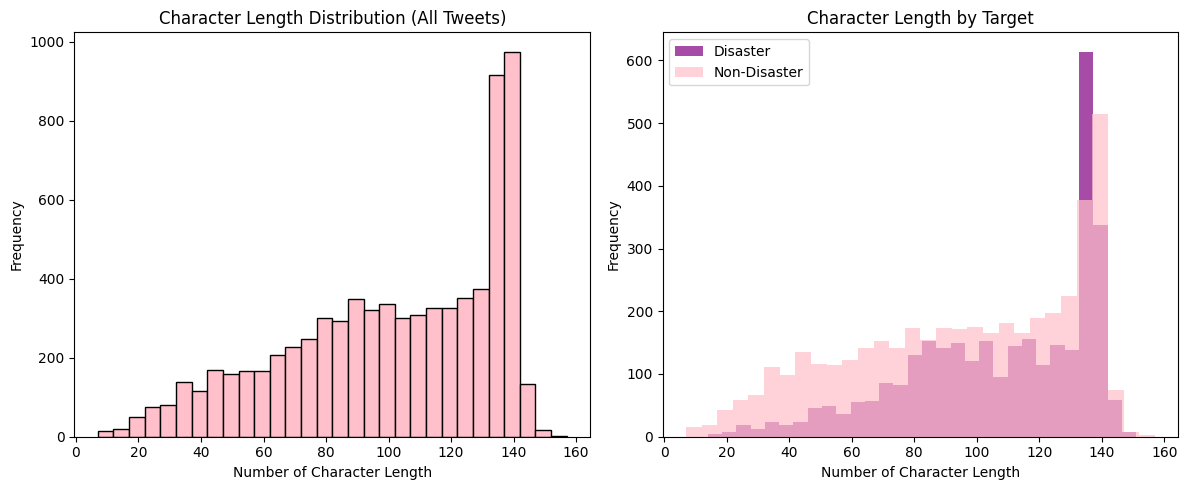

In [75]:
plot(df1, 'text', 'char_length')


#### Combined Text (Keyword + Location + Tweet)

In the second set of plots, the tweet text was combined with the `keyword` and `location` fields to enrich the textual input for the neural network.

As expected, the distribution shifts toward **larger character lengths**, since additional information from the keyword and location fields increases the total size of the text input. Despite this shift, the overall distribution pattern remains similar, and the relative comparison between disaster and non-disaster tweets is preserved.

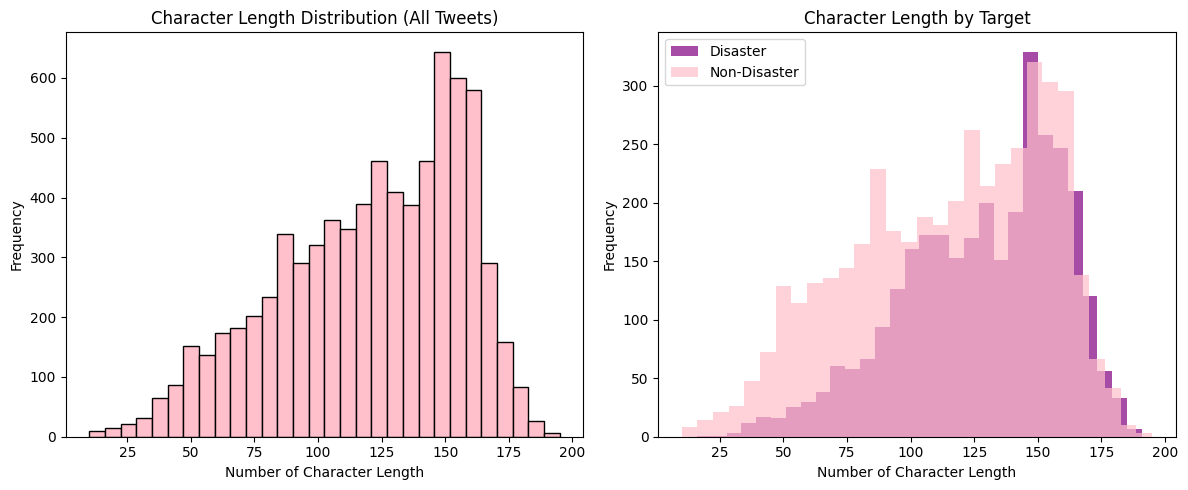

In [76]:
plot(df1, 'combined_text', 'char_length')

Overall, this analysis confirms that the dataset does not contain abnormal text lengths.

#### **2.3.2 Token length distributions**

To further analyze the textual characteristics of the dataset, the **token length** (number of words per tweet) was computed. Token length provides insight into how much information each tweet contains and helps identify unusually short or long texts.

Two analyses were performed:

1. **Original tweet text (`text`)**
2. **Combined text (`keyword + location + text`)**

In [77]:
def token_length(df, column):
    df['token_length'] = df[column].str.split().str.len()
    return df

#### Token Length for Original Tweet Text

Most tweets contain approximately **10 to 20 tokens**, with the distribution centered around **15 tokens**. This indicates that tweets in the dataset generally contain short sentences or brief descriptions. However, both distributions overlap significantly, meaning token length alone is **not sufficient to distinguish the two classes**.

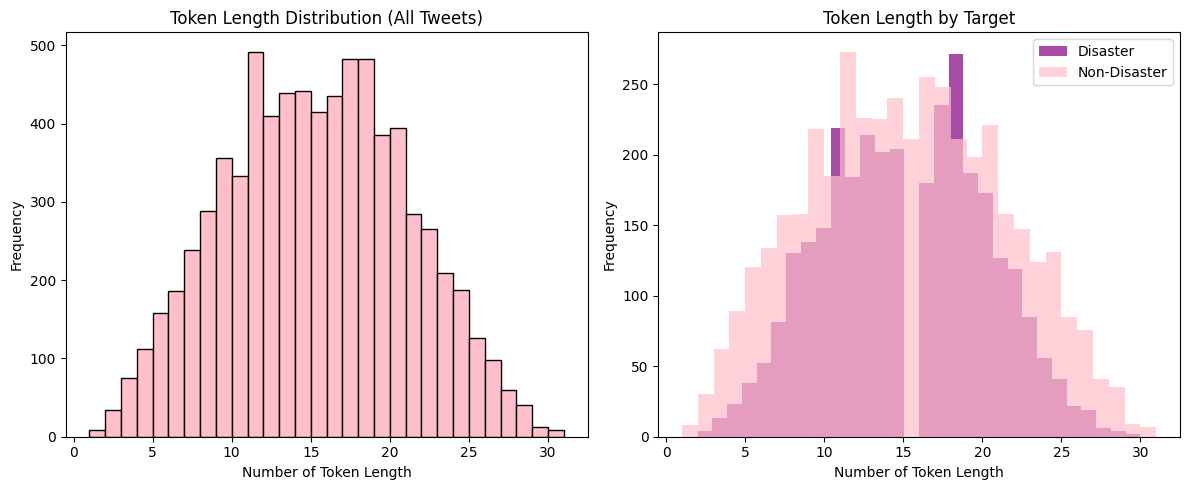

In [78]:
plot(df1, 'text', 'token_length')


#### Token Length for Combined Text
As expected, the token length distribution shifts toward **higher values**, since additional tokens from the keyword and location fields are added to each tweet. Most tweets now fall roughly between **12 and 25 tokens**, with some reaching **30 or more tokens**.
Despite this increase, the overall distribution pattern remains similar, and the relative relationship between disaster and non-disaster tweets is preserved.

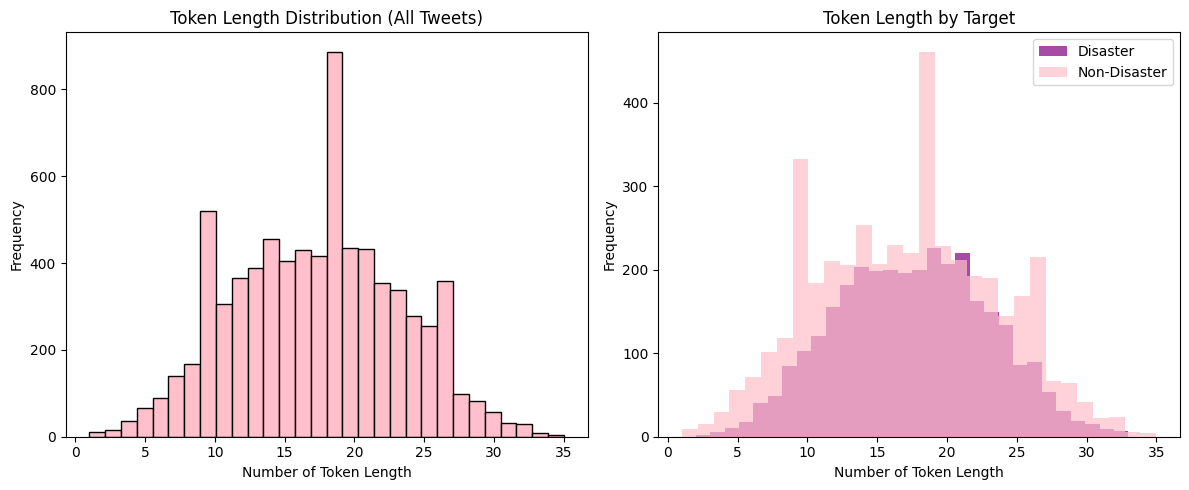

In [79]:
plot(df1, 'combined_text', 'token_length')

This analysis confirms that the textual inputs are within a reasonable size range for training natural language processing models.

### **2.4 URLs, mentions, hashtags, emojis extraction**


#### **2.4.1 URLs**

URLs were extracted from the tweet text using regular expressions to identify links embedded within tweets. The number of URLs present in each tweet was computed and used to analyze their distribution across the dataset.


In [80]:
def extract_urls(df, column):
    df['urls'] = df[column].apply(lambda x: re.findall(r'https?://\S+|www\.\S+', x))
    df['url_count'] = df['urls'].apply(len)
    return df

The first histogram shows the **overall distribution of URLs across all tweets**. Most tweets contain **either zero or one URL**, with a large concentration at zero. This indicates that the majority of tweets do not reference external resources.



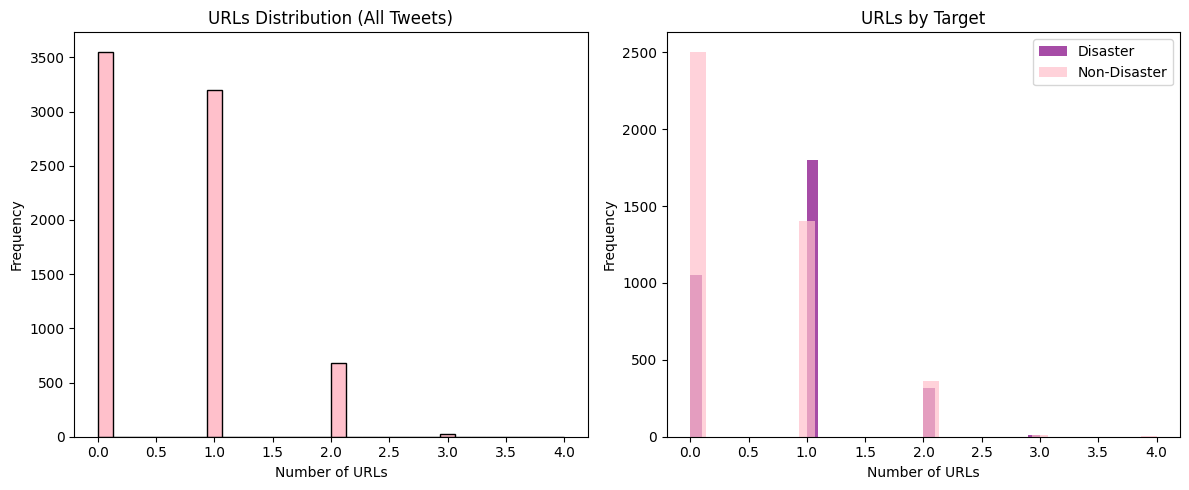

In [81]:
plot(df1, 'text', 'urls')

The second plot compares the distribution of URLs between **disaster-related tweets (`target = 1`)** and **non-disaster tweets (`target = 0`)**. Both classes show a similar pattern: most tweets contain no URLs, while a smaller portion includes one or occasionally two links. Tweets containing more than two URLs are extremely rare.

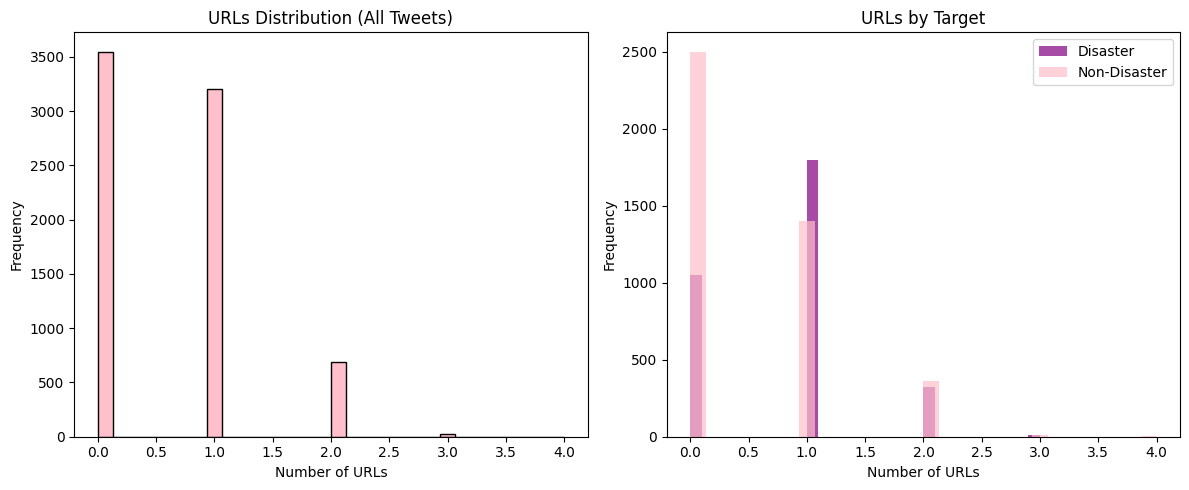

In [86]:
plot(df1, 'combined_text', 'urls')

#### **2.4.2 Hashtags**

Hashtags were extracted from the tweet text using regular expressions that detect words beginning with the `#` symbol. The number of hashtags present in each tweet was then computed to analyze how frequently hashtags appear in the dataset.



In [97]:
def extract_hashtags(df, column):
    df['hashtags'] = df[column].apply(lambda x: re.findall(r'#\w+', x))
    df['hashtag_count'] = df['hashtags'].apply(len)
    return df

The first histogram shows the **overall distribution of hashtags across all tweets**. The majority of tweets contain **no hashtags**, indicating that most messages are written without explicitly tagging topics. A smaller portion of tweets contains **one hashtag**, while tweets with two or more hashtags become progressively less frequent. Tweets containing a large number of hashtags are very rare and can be considered outliers.


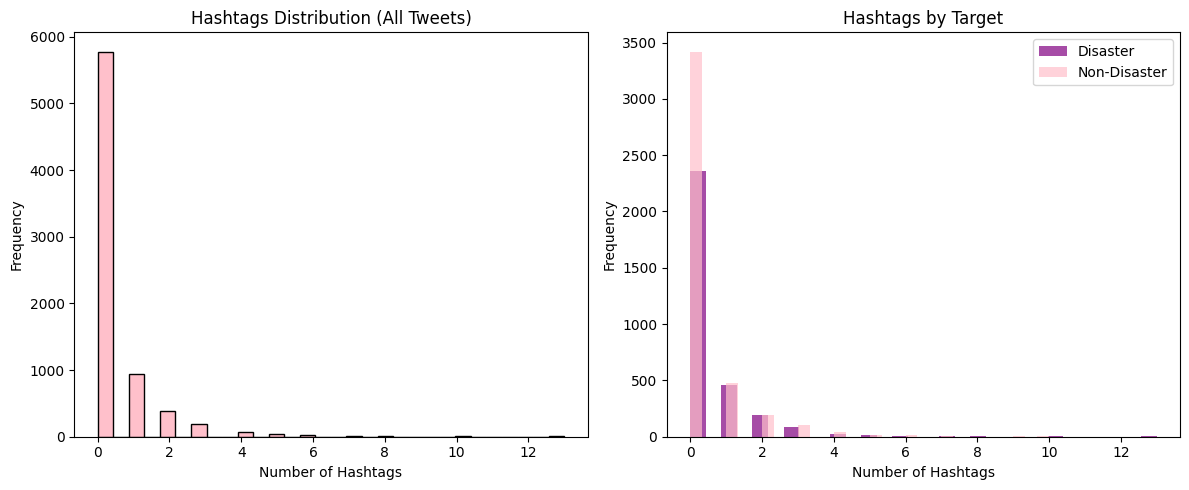

In [98]:
plot(df1, 'text', 'hashtags')



The second plot compares the number of hashtags between **disaster-related tweets (`target = 1`)** and **non-disaster tweets (`target = 0`)**. Both classes exhibit a similar distribution pattern. Most tweets in both categories contain zero hashtags, with the frequency decreasing as the number of hashtags increases.


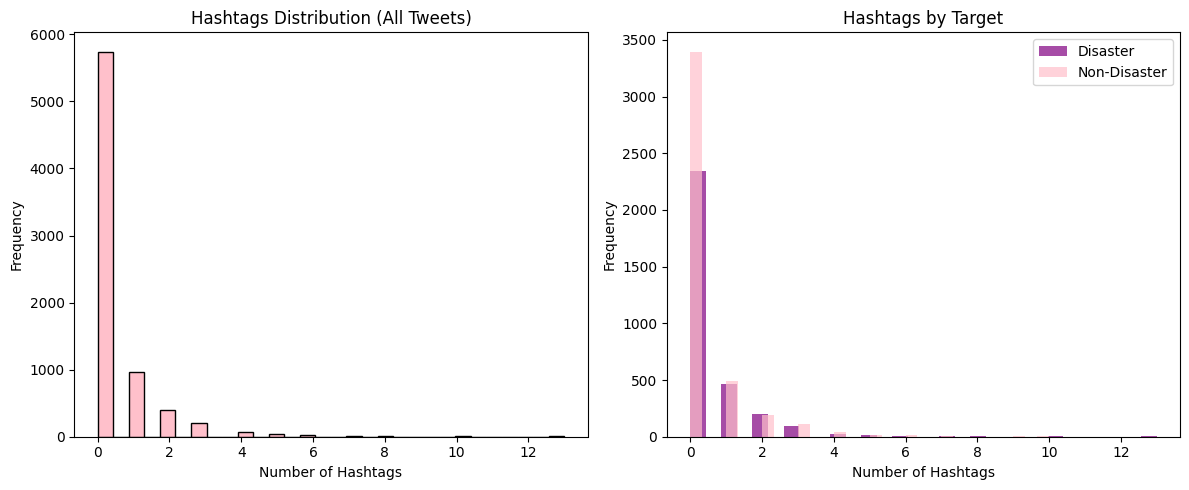

In [99]:
plot(df1, 'combined_text', 'hashtags')


Overall, hashtags provide additional contextual information about tweet topics, but their presence in this dataset appears limited and does not show strong discriminatory patterns between disaster and non-disaster tweets.

#### **2.4.3 Mentions**

User mentions were extracted from the tweet text using regular expressions to identify patterns beginning with `@`, which typically refer to other Twitter users. The number of mentions in each tweet was computed to analyze how frequently tweets reference other users.



In [82]:
def extract_mentions(df, column):
    df['mentions'] = df[column].apply(lambda x: re.findall(r'@\w+', x))
    df['mention_count'] = df['mentions'].apply(len)
    return df

The first histogram shows the **overall distribution of mentions across the dataset**. The majority of tweets contain **no mentions**, indicating that most tweets are standalone messages rather than direct interactions with other users. A smaller portion of tweets contains **one mention**, while tweets with multiple mentions appear only occasionally.

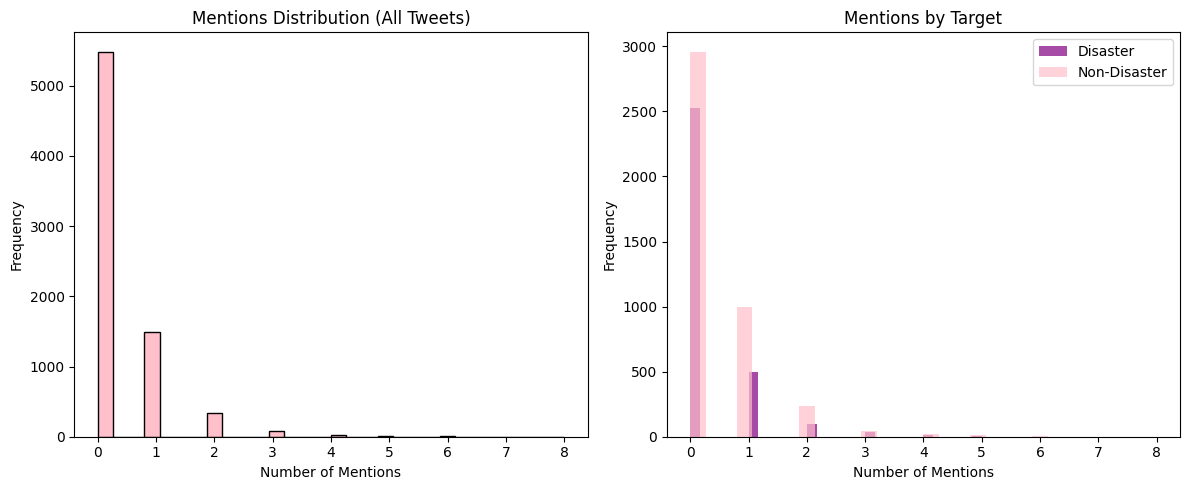

In [94]:
plot(df1, 'text', 'mentions')

The second plot compares the number of mentions between **disaster-related tweets (`target = 1`)** and **non-disaster tweets (`target = 0`)**. Both categories follow a very similar distribution pattern. Most tweets in both classes contain zero mentions, with a gradual decrease in frequency as the number of mentions increases.

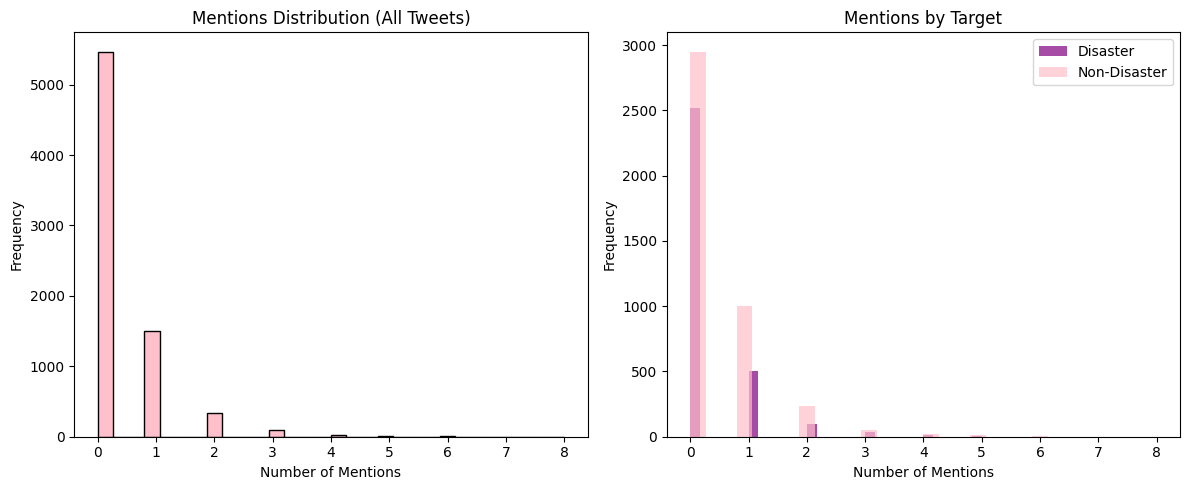

In [90]:
plot(df1, 'combined_text', 'mentions')


Overall, while mentions can provide contextual information about interactions between users, their presence in this dataset appears limited and does not show strong discriminatory patterns between disaster and non-disaster tweets.

#### **2.4.3 Emojis**

Emojis were extracted from the tweet text using Unicode-based regular expressions. However, the analysis revealed that no tweets in the dataset contain emojis. The distribution shows that the emoji count is zero for all tweets.

This indicates that emojis are not present in the dataset and therefore do not provide useful information for the classification task. As a result, emoji-related features are not considered further in the analysis.

In [84]:
def extract_emojis(df, column):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "]+",
        flags=re.UNICODE
    )

    df['emojis'] = df[column].apply(lambda x: emoji_pattern.findall(x))
    df['emoji_count'] = df['emojis'].apply(len)

    return df

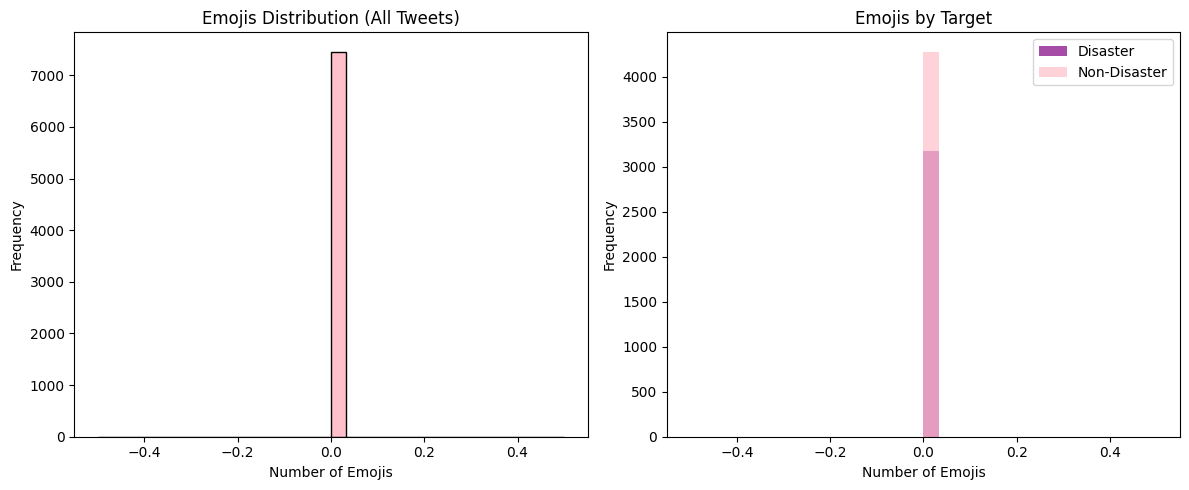

In [85]:
plot(df1, 'text', 'emojis')

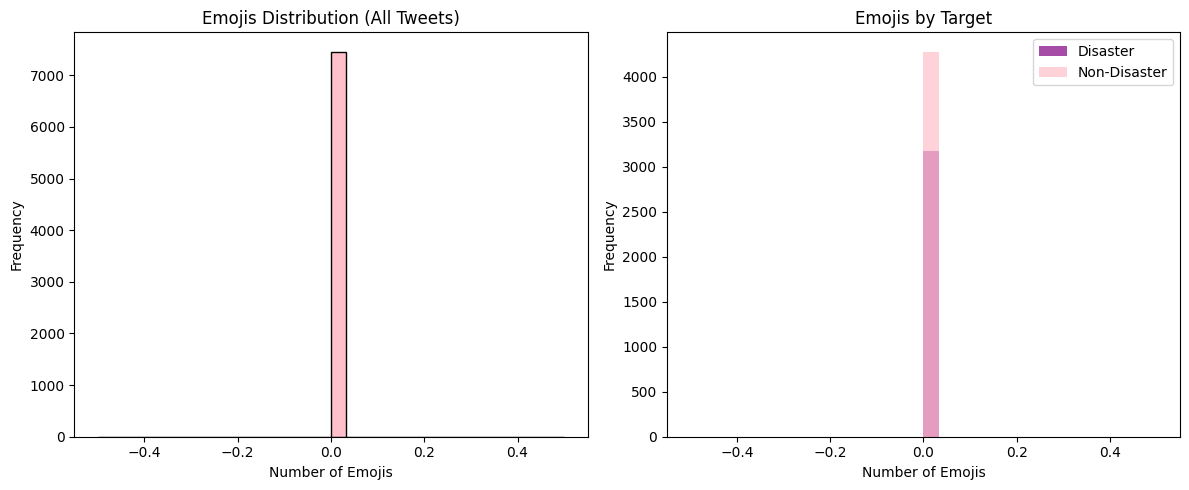

In [87]:
plot(df1, 'combined_text', 'emojis')

## **3. Lexical and Surface-Level Analysis**

### **3.1 Unigram, bigram, trigram frequency analysis**

In [108]:
def plot_top(df, column, type):

    if type == "unigram":
        ngram = (1,1)
        title = "Top 20 Unigrams"

    elif type == "bigram":
        ngram = (2,2)
        title = "Top 20 Bigrams"

    elif type == "trigram":
        ngram = (3,3)
        title = "Top 20 Trigrams"

    else:
        raise ValueError("type must be 'unigram', 'bigram', or 'trigram'")

    # Compute frequencies
    overall = get_ngram(df, column, ngram)
    class0 = get_ngram(df[df['target'] == 0], column, ngram)
    class1 = get_ngram(df[df['target'] == 1], column, ngram)

    # Smaller figure
    fig, ax = plt.subplots(1, 3, figsize=(15,4))

    # Overall
    ax[0].barh(overall['term'], overall['count'], color="purple")
    ax[0].set_title("Overall")
    ax[0].invert_yaxis()

    # Class 0
    ax[1].barh(class0['term'], class0['count'], color="pink")
    ax[1].set_title("Target = 0 (Non-Disaster)")
    ax[1].invert_yaxis()

    # Class 1
    ax[2].barh(class1['term'], class1['count'], color="purple")
    ax[2].set_title("Target = 1 (Disaster)")
    ax[2].invert_yaxis()

    for a in ax:
        a.set_xlabel("Frequency")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [106]:
def get_ngram(df, column, ngram_range, top_n=20):

    vectorizer = CountVectorizer(ngram_range=ngram_range, stop_words='english')
    X = vectorizer.fit_transform(df[column])

    counts = X.sum(axis=0).A1
    vocab = vectorizer.get_feature_names_out()
    freq = pd.DataFrame({'term': vocab, 'count': counts})
    freq = freq.sort_values(by='count', ascending=False).head(top_n)

    return freq

#### **3.1.1 Unigram**

The unigram analysis examines the frequency of individual words in the dataset. The overall distribution shows that some tokens such as **"http"**, **"https"**, and **"amp"** appear very frequently. These tokens are related to URLs and HTML entities that commonly appear in tweets, indicating that many tweets include links or encoded characters.

When comparing the two classes, some differences become visible. In **non-disaster tweets (target = 0)**, common words include more general terms such as *video*, *youtube*, or conversational expressions. In contrast, **disaster-related tweets (target = 1)** contain more event-related words such as *disaster*, *police*, *storm*, *crash*, *wildfire*, and *emergency*. These words are directly associated with real-world incidents and emergencies.



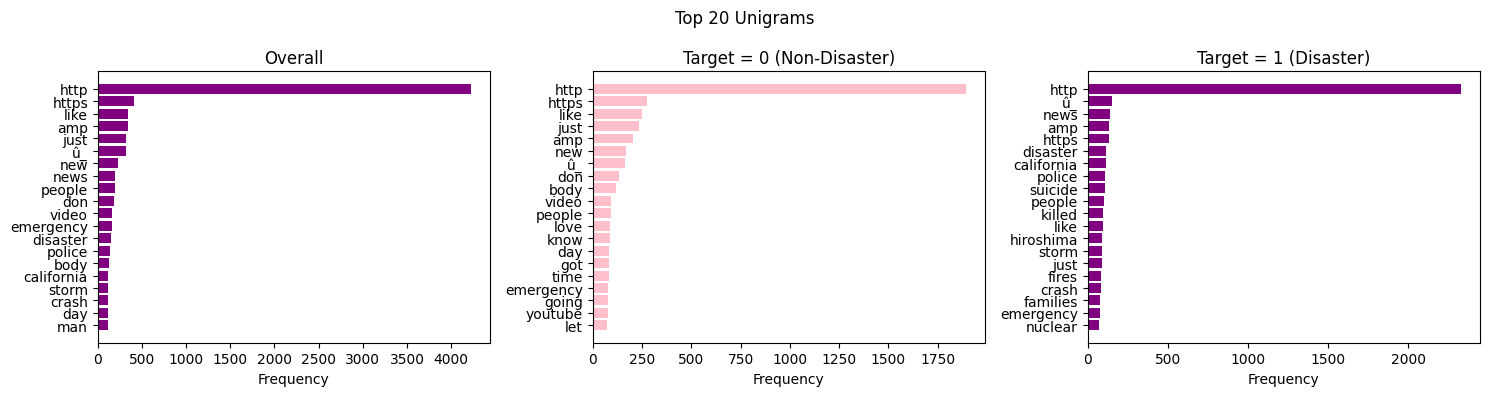

In [109]:
plot_top(df1, 'text', 'unigram')

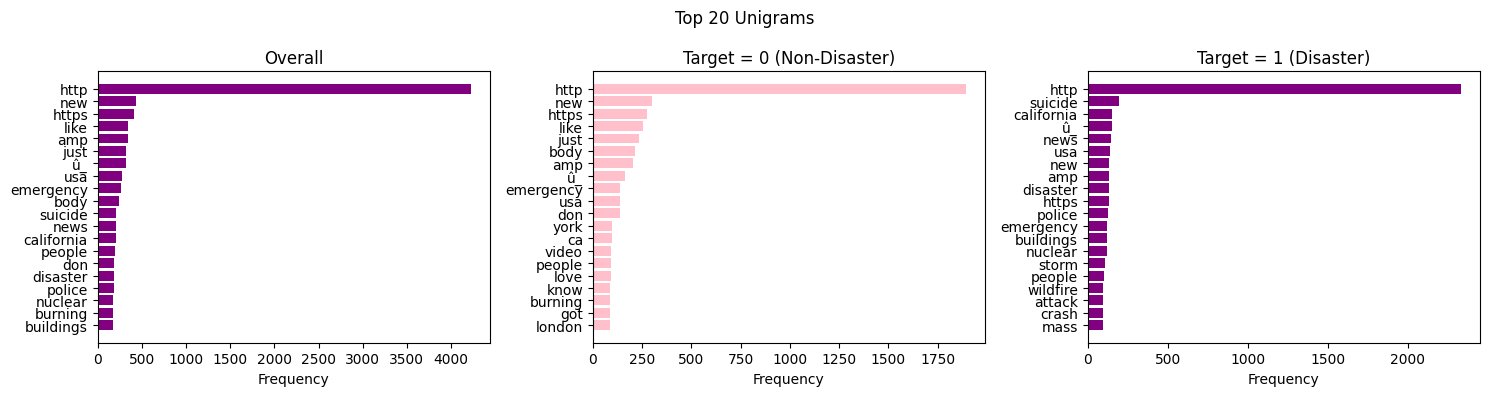

In [110]:
plot_top(df1, 'combined_text', 'unigram')

This suggests that disaster tweets contain more **event-specific vocabulary**, while non-disaster tweets tend to contain more **general or media-related language**.

#### **3.1.2 Bigram**

Bigram analysis considers pairs of consecutive words, allowing us to identify commonly occurring phrases rather than individual tokens.

The overall bigram distribution highlights phrases such as **"suicide bomber"**, **"northern california"**, **"oil spill"**, and **"burning buildings"**, which correspond to descriptions of disaster events. These phrases provide stronger contextual signals compared to single words.

In **non-disaster tweets**, common bigrams include phrases such as *youtube video* or *cross body*, which are less related to real emergency situations. On the other hand, **disaster tweets frequently contain bigrams related to real incidents**, including *suicide bomber*, *oil spill*, and *burning buildings*.



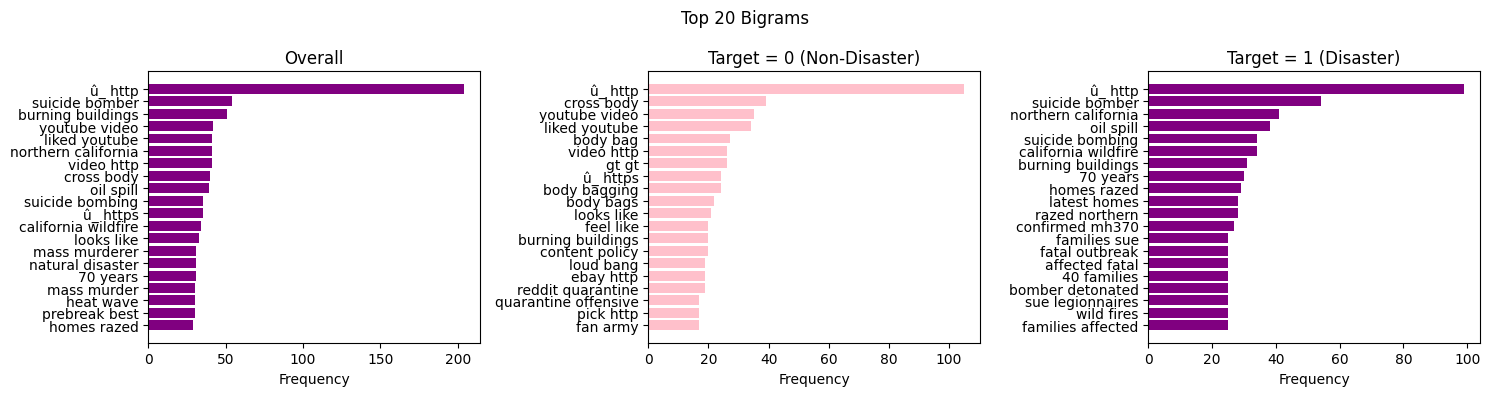

In [111]:
plot_top(df1, 'text', 'bigram')

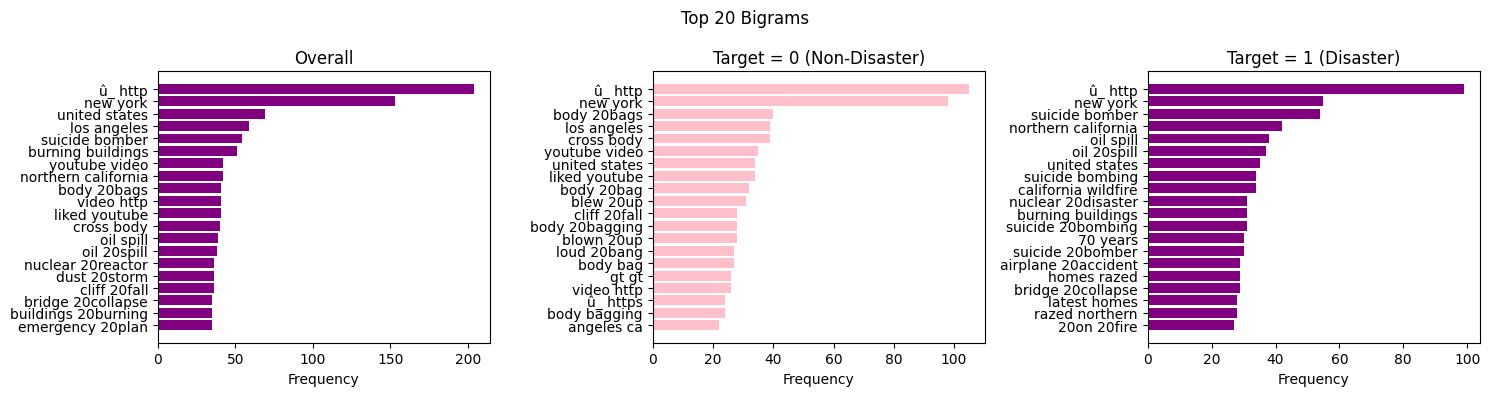

In [112]:
plot_top(df1, 'combined_text', 'bigram')

This indicates that bigram analysis captures **more informative contextual relationships** between words and helps distinguish disaster-related language patterns.

#### **3.1.3 Trigram**

Trigram analysis extends this idea by examining sequences of three consecutive words. This helps capture more complete expressions describing events.

The results reveal phrases such as **"northern california wildfire"**, **"homes razed northern"**, and **"families affected fatal"**, which provide more detailed descriptions of disaster scenarios. These trigrams typically appear in tweets describing news reports, emergency updates, or incident summaries.

In contrast, non-disaster tweets tend to contain more **general expressions or media-related phrases**, such as references to videos or online discussions.



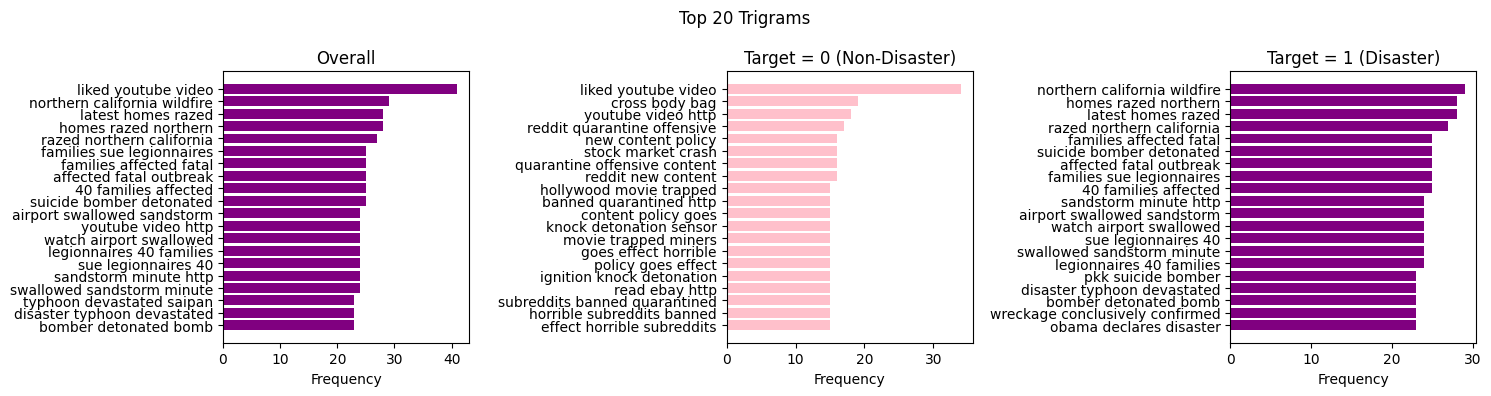

In [114]:
plot_top(df1, 'text', 'trigram')

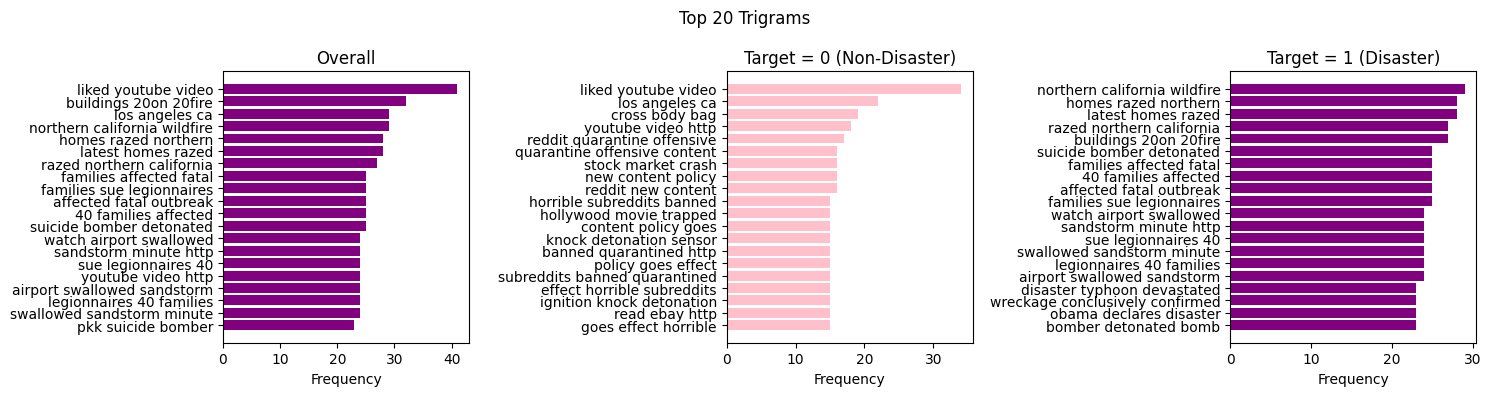

In [113]:
plot_top(df1, 'combined_text', 'trigram')


Overall, trigram analysis highlights that disaster tweets frequently contain **structured event descriptions**, while non-disaster tweets often include **informal or entertainment-related content**.

### **3.2 Hashtag analysis**

To further analyze the relationships between hashtags, a co-occurrence analysis was performed.  
This analysis identifies pairs of hashtags that appear together within the same tweet, allowing us to observe associations between topics and detect patterns in how disaster-related information is shared.

When examining tweets by class, differences emerge:

- **Non-disaster tweets** tend to contain hashtags related to entertainment or general topics, such as music or trending tags (e.g., `#Dubstep`, `#TrapMusic`, `#EDM`).
- **Disaster-related tweets** more often include hashtags associated with **news, locations, or real-world events**, such as `#BBC`, `#CNN`, `#News`, and regional references.


In [121]:
def plot_cooccurrence(df):

    overall = hashtag_cooccurrence(df)
    class0 = hashtag_cooccurrence(df[df['target'] == 0])
    class1 = hashtag_cooccurrence(df[df['target'] == 1])

    fig, ax = plt.subplots(1, 3, figsize=(14,5))

    # Overall
    ax[0].barh(overall['pair'], overall['count'], color="purple")
    ax[0].set_title("Overall")
    ax[0].invert_yaxis()

    # Class 0
    ax[1].barh(class0['pair'], class0['count'], color="pink")
    ax[1].set_title("Target = 0 (Non-Disaster)")
    ax[1].invert_yaxis()

    # Class 1
    ax[2].barh(class1['pair'], class1['count'], color="purple")
    ax[2].set_title("Target = 1 (Disaster)")
    ax[2].invert_yaxis()

    for a in ax:
        a.set_xlabel("Frequency")

    plt.suptitle("Top Hashtag Co-occurrences")
    plt.tight_layout()
    plt.show()


In [122]:
def hashtag_cooccurrence(df, top_n=20):
    pairs = []

    for tags in df['hashtags']:
        if len(tags) > 1:
            pairs.extend(combinations(tags, 2))

    pair_counts = Counter(pairs)
    pair_top = pair_counts.most_common(top_n)
    pair_df = pd.DataFrame(pair_top, columns=['pair', 'count'])
    pair_df['pair'] = pair_df['pair'].apply(lambda x: f"{x[0]} + {x[1]}")

    return pair_df

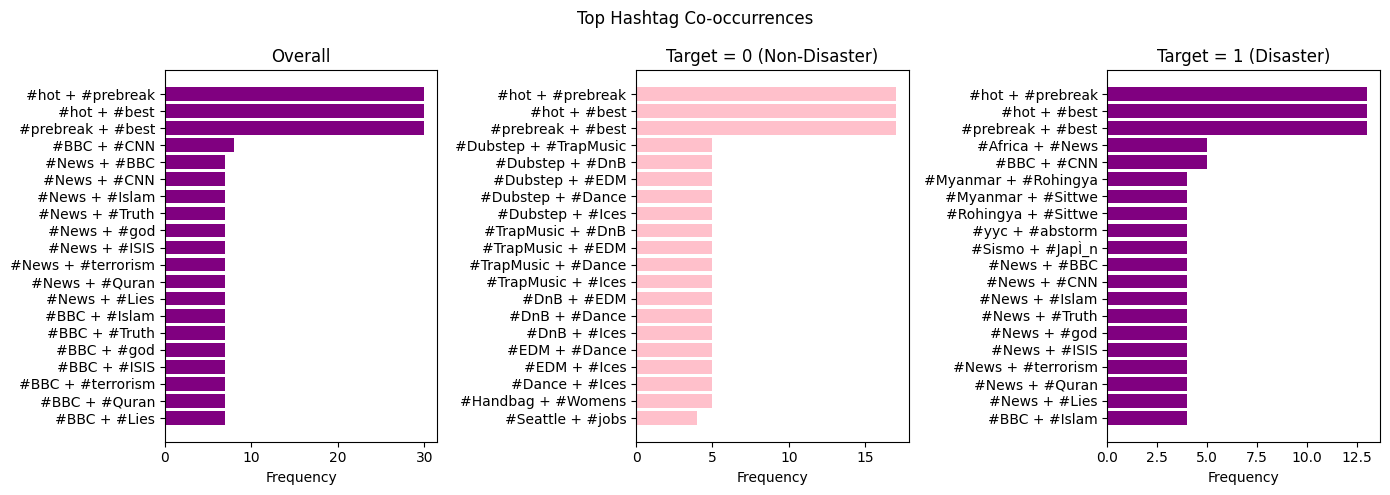

In [124]:
plot_cooccurrence(df1)

### **3.3 Stopword vs content-word comparison**


To better understand the linguistic structure of the tweets, we analyzed the distribution of **stopwords** and **content words**.  
Stopwords are common grammatical words such as *the, a, in, to,* and *of*, which generally carry little semantic meaning but help structure sentences.  
Content words, on the other hand, represent the informative vocabulary that conveys the main meaning of the tweet.



In [138]:
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ale\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [142]:
def stopword_content(df, column):

    stopword_counts = []
    content_counts = []
    stopword_lists = []

    for text in df[column]:

        stop_count = 0
        content_count = 0
        stop_list = []

        tokens = text.lower().split()

        for word in tokens:

            if word in stop_words:
                stop_count = stop_count + 1
                stop_list.append(word)

            else:
                content_count = content_count + 1

        stopword_counts.append(stop_count)
        content_counts.append(content_count)
        stopword_lists.append(stop_list)

    df['stopword_count'] = stopword_counts
    df['contentword_count'] = content_counts
    df['stopwords'] = stopword_lists

    return df

In [147]:
def plot_stopword_counts(df, column):
    df = stopword_content(df, column)
    overall = df['stopword_count']
    class0 = df[df['target'] == 0]['stopword_count']
    class1 = df[df['target'] == 1]['stopword_count']

    fig, ax = plt.subplots(1, 3, figsize=(14,5))

    # Overall
    ax[0].hist(overall, bins=20, color="purple")
    ax[0].set_title("Overall")
    ax[0].set_xlabel("Number of Stopwords")
    ax[0].set_ylabel("Frequency")

    # Class 0
    ax[1].hist(class0, bins=20, color="pink")
    ax[1].set_title("Target = 0 (Non-Disaster)")
    ax[1].set_xlabel("Number of Stopwords")

    # Class 1
    ax[2].hist(class1, bins=20, color="purple")
    ax[2].set_title("Target = 1 (Disaster)")
    ax[2].set_xlabel("Number of Stopwords")

    plt.suptitle("Stopword Count Distribution")
    plt.tight_layout()
    plt.show()

Overall, most tweets contain a relatively small number of stopwords, which is expected given the short length of tweets. The distributions for disaster and non-disaster tweets are similar, though disaster tweets tend to show a slightly wider spread, suggesting that some disaster-related messages include longer descriptive structures.

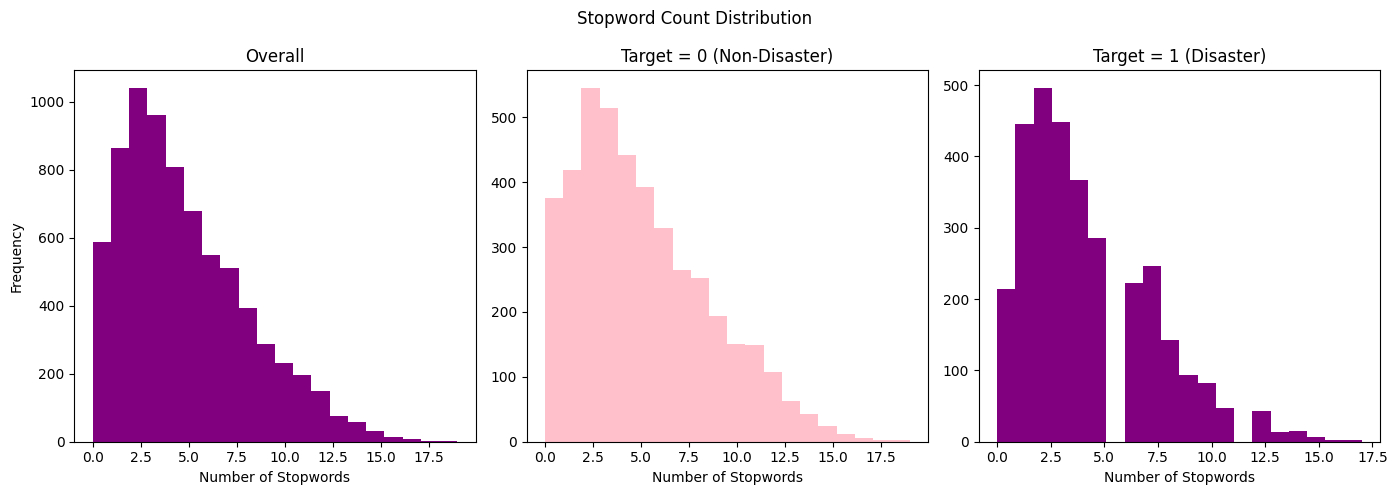

In [148]:
plot_stopword_counts(df1, 'text')

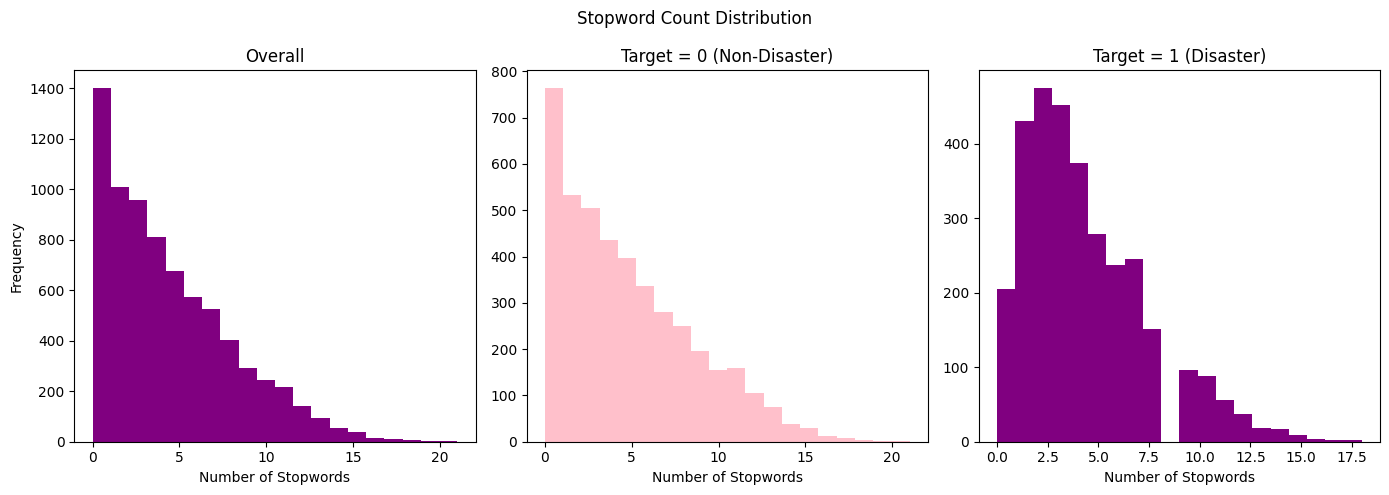

In [149]:
plot_stopword_counts(df1, 'combined_text')

In [150]:
def top_stopwords(df, top_n=20):

    all_stopwords = []

    for stop_list in df['stopwords']:
        for word in stop_list:
            all_stopwords.append(word)

    counter = Counter(all_stopwords)

    top = counter.most_common(top_n)

    df_stop = pd.DataFrame(top, columns=['word','count'])

    return df_stop

In [151]:
def plot_top_stopwords(df):

    overall = top_stopwords(df)
    class0 = top_stopwords(df[df['target'] == 0])
    class1 = top_stopwords(df[df['target'] == 1])

    fig, ax = plt.subplots(1, 3, figsize=(14,5))

    # Overall
    ax[0].barh(overall['word'], overall['count'], color="purple")
    ax[0].set_title("Overall")
    ax[0].invert_yaxis()

    # Class 0
    ax[1].barh(class0['word'], class0['count'], color="pink")
    ax[1].set_title("Target = 0 (Non-Disaster)")
    ax[1].invert_yaxis()

    # Class 1
    ax[2].barh(class1['word'], class1['count'], color="purple")
    ax[2].set_title("Target = 1 (Disaster)")
    ax[2].invert_yaxis()

    for a in ax:
        a.set_xlabel("Frequency")

    plt.suptitle("Top Stopwords")
    plt.tight_layout()
    plt.show()

This analysis highlights that while stopwords themselves do not carry strong semantic meaning, their distribution can still reflect differences in how information is communicated across tweet types.

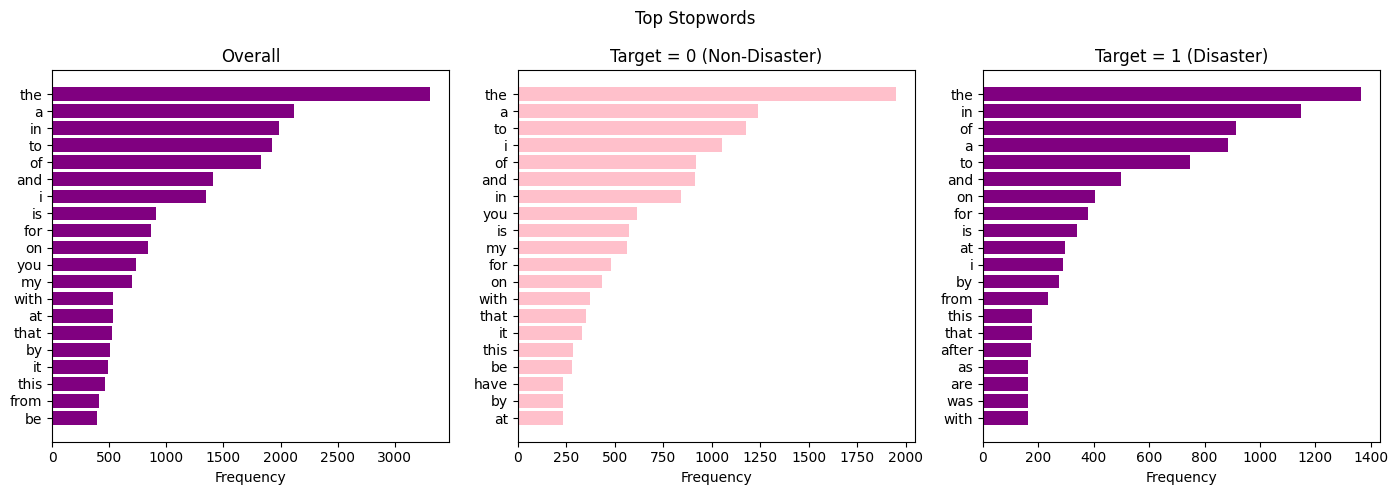

In [152]:
plot_top_stopwords(df1)

### **3.4 Punctuation and capitalization patterns**

To analyze stylistic signals in the tweets, we examined three textual features related to punctuation and capitalization:

- **Exclamation marks (`!`)**
- **Question marks (`?`)**
- **Uppercase letter ratio**

These features can indicate urgency, emotional intensity, or emphasis in written communication, which may differ between disaster-related and non-disaster tweets.



In [153]:
def punctuation_capitalization(df, column):

    exclam_counts = []
    question_counts = []
    uppercase_ratio = []

    for text in df[column]:

        exclam_count = text.count("!")
        question_count = text.count("?")

        total_letters = 0
        uppercase_letters = 0

        for char in text:

            if char.isalpha():
                total_letters = total_letters + 1

                if char.isupper():
                    uppercase_letters = uppercase_letters + 1

        if total_letters == 0:
            ratio = 0
        else:
            ratio = uppercase_letters / total_letters

        exclam_counts.append(exclam_count)
        question_counts.append(question_count)
        uppercase_ratio.append(ratio)

    df['exclamation_count'] = exclam_counts
    df['question_count'] = question_counts
    df['uppercase_ratio'] = uppercase_ratio

    return df

In [156]:
def plot_punctuation(df, column, feature, title):
    df = punctuation_capitalization(df, column)

    overall = df[feature]
    class0 = df[df['target'] == 0][feature]
    class1 = df[df['target'] == 1][feature]

    fig, ax = plt.subplots(1, 3, figsize=(14,5))

    # Overall
    ax[0].hist(overall, bins=20, color="purple")
    ax[0].set_title("Overall")

    # Non-disaster
    ax[1].hist(class0, bins=20, color="pink")
    ax[1].set_title("Target = 0 (Non-Disaster)")

    # Disaster
    ax[2].hist(class1, bins=20, color="purple")
    ax[2].set_title("Target = 1 (Disaster)")

    for a in ax:
        a.set_xlabel(title)
        a.set_ylabel("Frequency")

    plt.suptitle(title + " Distribution")
    plt.tight_layout()
    plt.show()

#### **3.4.1 Exclamation Marks**

The distribution of exclamation marks shows that the majority of tweets contain **zero or very few exclamation marks**. This suggests that most tweets in the dataset are written in a relatively neutral tone. When comparing tweet classes, the patterns are generally similar between disaster and non-disaster tweets.



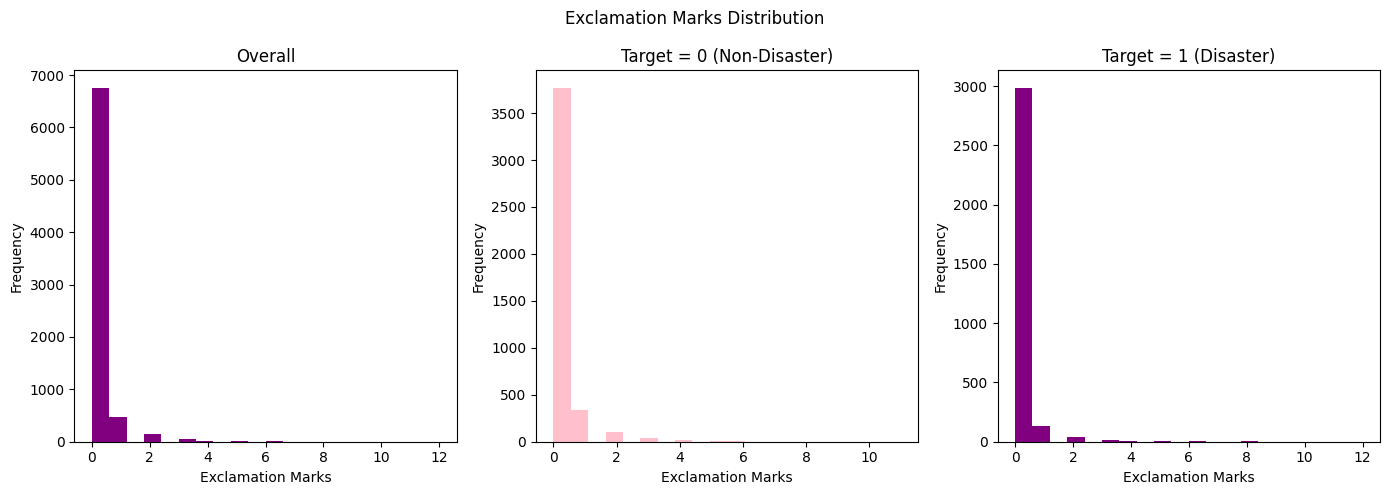

In [157]:
plot_punctuation(df1, 'text','exclamation_count', 'Exclamation Marks')


#### **3.4.2 Question Marks**

The distribution of question marks indicates that most tweets contain **no question marks**, meaning that tweets are primarily used to **report or describe events rather than ask questions**. Both disaster and non-disaster tweets show similar patterns, though non-disaster tweets appear to include slightly more questions, likely due to conversational or informal interactions.




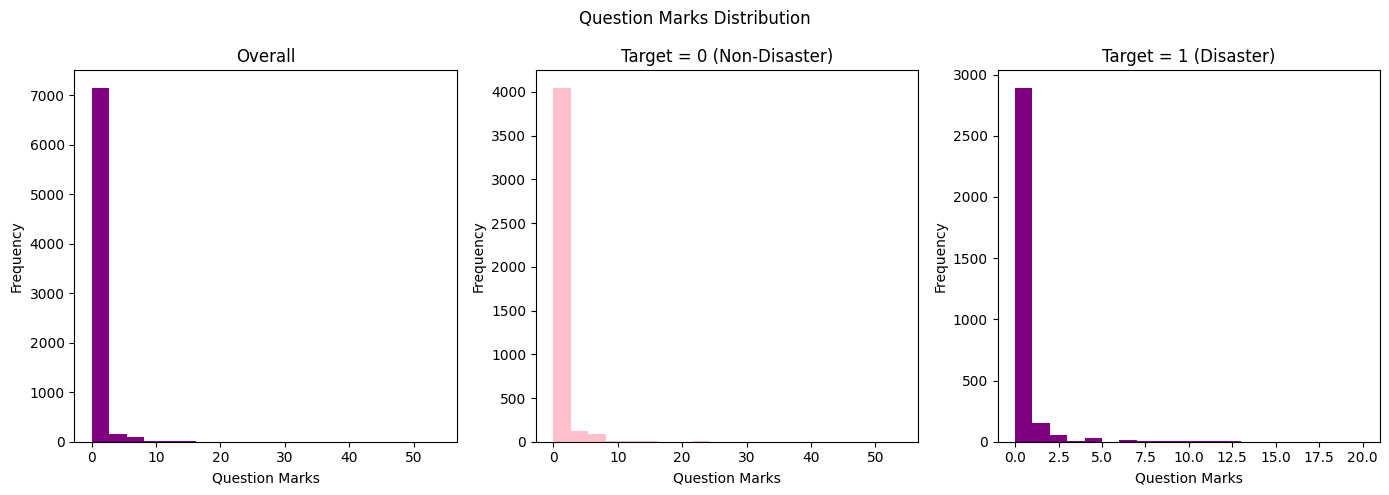

In [158]:
plot_punctuation(df1, 'text', 'question_count', 'Question Marks')


#### **3.4.3 Uppercase Ratio**

The uppercase ratio measures the proportion of uppercase letters relative to all alphabetic characters in a tweet. In most cases, the ratio is **relatively low**, indicating that tweets are primarily written in normal sentence case.

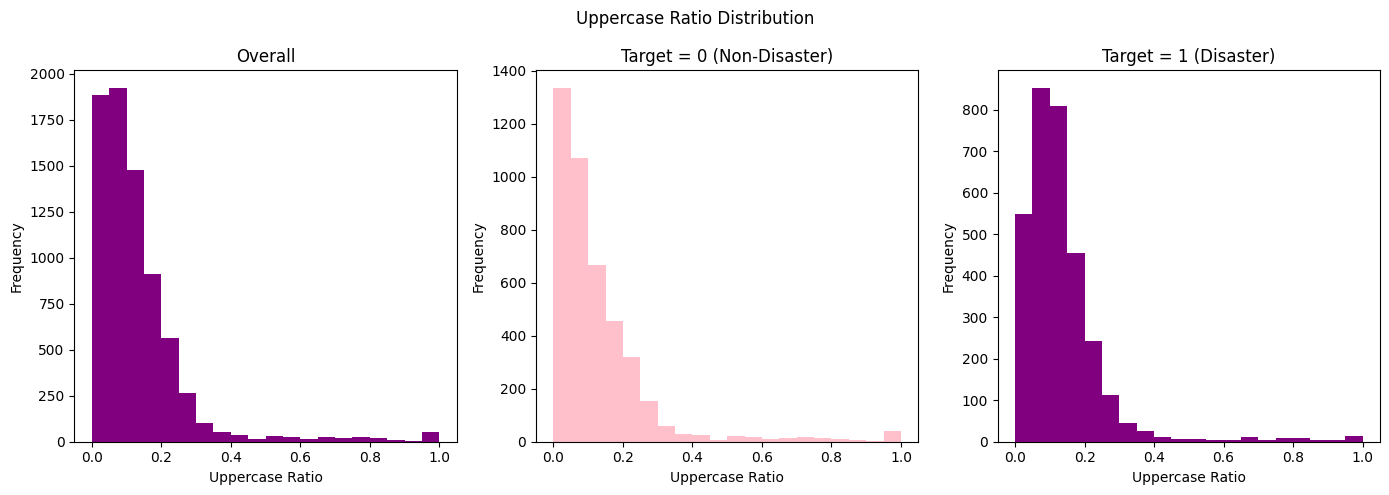

In [159]:
plot_punctuation(df1, 'text','uppercase_ratio', 'Uppercase Ratio')

## **4. Language and Encoding**

### **4.1 Language detection**

The results show that the dataset is overwhelmingly dominated by **English (`en`)**, which accounts for the vast majority of tweets across both classes. A very small number of tweets were detected as other languages such as **German (`de`)**, **Catalan (`ca`)**, **French (`fr`)**, and **Italian (`it`)**, but their frequencies are negligible compared to English.


In [164]:
def detect_language(df, column):
    languages = []

    for text in df[column]:
        try:
            lang = detect(text)
        except:
            lang = "unknown"

        languages.append(lang)

    df['language'] = languages

    return df

In [174]:

def plot_languages(df, column):

    df = detect_language(df, column)

    overall = df['language'].value_counts().head(10)

    class0 = df[df['target'] == 0]['language'].value_counts().head(10)

    class1 = df[df['target'] == 1]['language'].value_counts().head(10)

    fig, ax = plt.subplots(1, 3, figsize=(14,5))

    # Overall
    ax[0].barh(overall.index, overall.values, color="purple")
    ax[0].set_title("Overall")
    ax[0].invert_yaxis()

    # Class 0
    ax[1].barh(class0.index, class0.values, color="pink")
    ax[1].set_title("Target = 0 (Non-Disaster)")
    ax[1].invert_yaxis()

    # Class 1
    ax[2].barh(class1.index, class1.values, color="purple")
    ax[2].set_title("Target = 1 (Disaster)")
    ax[2].invert_yaxis()

    for a in ax:
        a.set_xlabel("Number of Tweets")

    plt.suptitle("Top Languages in Tweets")

    plt.tight_layout()
    plt.show()

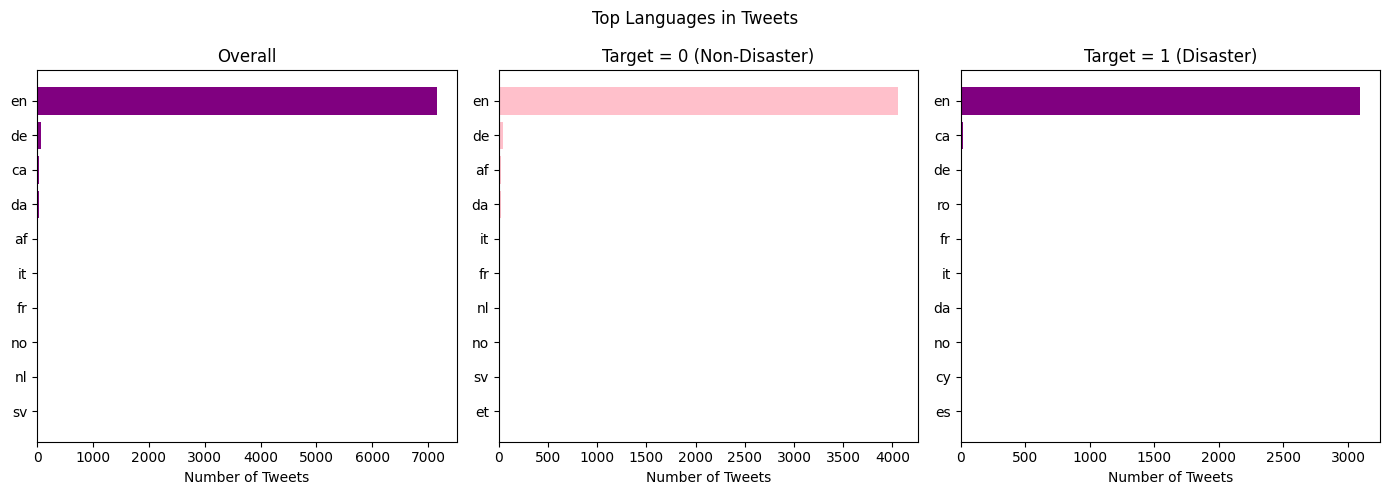

In [175]:
plot_languages(df1, 'text')

 
Overall, the analysis indicates that the dataset can be considered **effectively monolingual**, and therefore no additional multilingual preprocessing or filtering is required for the modeling stage.

### **4.2 Encoding and normalization issues**

To ensure the dataset can be reliably processed by NLP models, we analyzed the presence of **non-ASCII characters** in the tweets. Non-ASCII characters include accented letters, Unicode symbols, or encoding artifacts that may appear during data collection or text scraping.



In [181]:
def detect_non_ascii(df, column):
    non_ascii_counts = []

    for text in df[column]:
        count = 0
        for char in text:
            if ord(char) > 127:
                count = count + 1
        non_ascii_counts.append(count)

    df['non_ascii_count'] = non_ascii_counts

    return df

In [182]:
def plot_non_ascii(df):
    df = detect_non_ascii(df, 'text')

    overall = df['non_ascii_count']
    class0 = df[df['target'] == 0]['non_ascii_count']
    class1 = df[df['target'] == 1]['non_ascii_count']

    fig, ax = plt.subplots(1, 3, figsize=(14,5))

    # Overall
    ax[0].hist(overall, bins=20, color="purple")
    ax[0].set_title("Overall")

    # Class 0
    ax[1].hist(class0, bins=20, color="pink")
    ax[1].set_title("Target = 0 (Non-Disaster)")

    # Class 1
    ax[2].hist(class1, bins=20, color="purple")
    ax[2].set_title("Target = 1 (Disaster)")

    for a in ax:
        a.set_xlabel("Number of Non-ASCII Characters")
        a.set_ylabel("Frequency")

    plt.suptitle("Non-ASCII Character Distribution")

    plt.tight_layout()
    plt.show()

The results show that the vast majority of tweets contain **zero non-ASCII characters**, indicating that the dataset is mostly composed of standard ASCII text. A small number of tweets contain a few non-ASCII characters, which may correspond to accented characters, special symbols, or encoding artifacts.


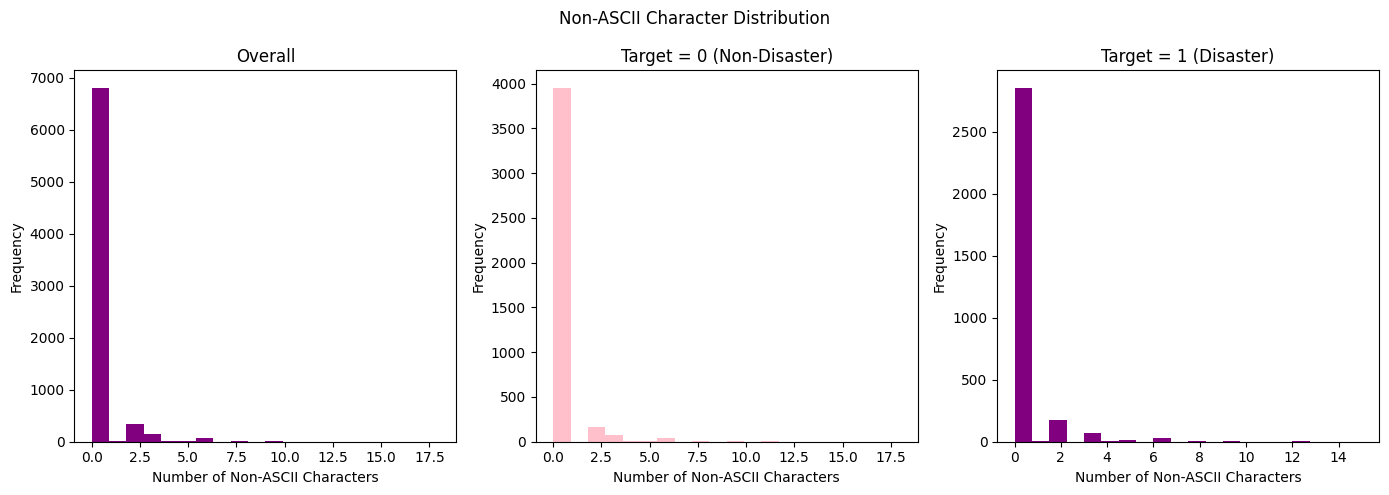

In [183]:
plot_non_ascii(df1)

## **5. Temporal and Geographic Analysis**


Temporal analysis aims to examine how tweet activity evolves over time, such as identifying spikes in tweet frequency by hour, day, or week. However, the dataset used in this study does not contain any timestamp or temporal metadata associated with the tweets.

Because no time-related information is available, it is not possible to analyze tweet frequency over time or identify temporal trends in disaster-related tweets. Therefore, temporal analysis cannot be performed for this dataset.

### **5.1 Geographic information analysis**


The geographic analysis was conducted using the user-declared `location` field from the dataset. Since Twitter allows users to freely enter their location, the values in this column are highly heterogeneous and often contain informal or ambiguous descriptions.



In [205]:
def top_locations(df, top_n=20):

    locations = df['location'].dropna()

    locations = locations.str.lower()

    location_counts = locations.value_counts().head(top_n)

    location_df = location_counts.reset_index()

    location_df.columns = ['location','count']

    return location_df



In [200]:
def plot_locations(df):

    overall = top_locations(df)
    class0 = top_locations(df[df['target'] == 0])
    class1 = top_locations(df[df['target'] == 1])

    fig, ax = plt.subplots(1,3, figsize=(14,5))

    # Overall
    ax[0].barh(overall['location'], overall['count'], color="purple")
    ax[0].set_title("Overall")
    ax[0].invert_yaxis()

    # Non-disaster
    ax[1].barh(class0['location'], class0['count'], color="pink")
    ax[1].set_title("Target = 0 (Non-Disaster)")
    ax[1].invert_yaxis()

    # Disaster
    ax[2].barh(class1['location'], class1['count'], color="purple")
    ax[2].set_title("Target = 1 (Disaster)")
    ax[2].invert_yaxis()

    for a in ax:
        a.set_xlabel("Number of Tweets")

    plt.suptitle("Top User-Declared Locations")
    plt.tight_layout()
    plt.show()

In [207]:
df2 = df1.dropna()

The results reveal that most identifiable locations correspond to the United States and major English-speaking cities such as New York and London. This indicates a geographic bias in the dataset toward English-speaking regions.


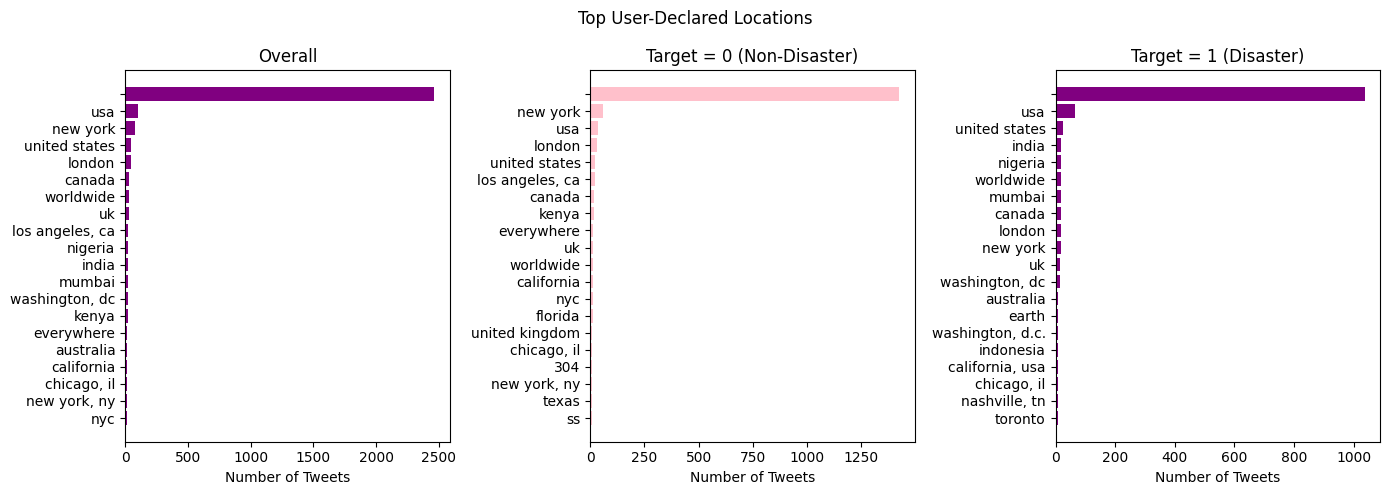

In [208]:
plot_locations(df2)

## **6. Label and Class Analysis**

### **6.1 Class distribution and imbalance**


In [209]:
def class_distribution(df):

    counts = df['target'].value_counts().sort_index()

    proportions = df['target'].value_counts(normalize=True).sort_index()

    class_df = pd.DataFrame({
        'class': ['Non-Disaster','Disaster'],
        'count': counts.values,
        'percentage': (proportions.values * 100)
    })

    return class_df

In [213]:
def plot_class_proportion(df):

    counts = df['target'].value_counts().sort_index()

    labels = ['Non-Disaster', 'Disaster']

    colors = ['#f4a3b4', '#6a0dad']  

    plt.figure(figsize=(6,6))

    plt.pie(
        counts.values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        wedgeprops={'edgecolor':'white','linewidth':2},
        textprops={'fontsize':11}
    )

    plt.title("Class Distribution of Tweets", fontsize=14)

    plt.axis('equal')

    plt.show()

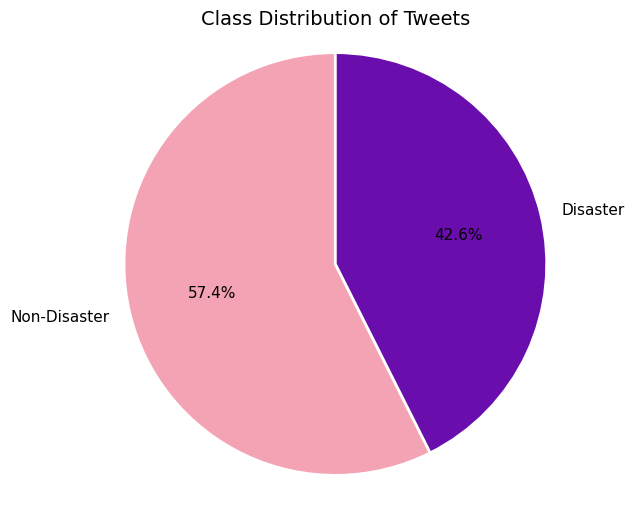

In [214]:
plot_class_proportion(df1)

The dataset contains two classes: disaster-related tweets (target = 1) and non-disaster tweets (target = 0). The class distribution shows that approximately **57.4%** of the tweets correspond to non-disaster events, while **42.6%** correspond to disaster-related tweets.

Although the dataset is relatively balanced, there is a slight dominance of the non-disaster class. 